# Pipeline Multimodal CNN + NLP — Diagnosis Penyakit Unggas

**Framework:** TensorFlow / Keras  
**Input:** Citra feses (CNN) + Gejala klinis teks (NLP)  
**Output:** 4 kelas — `eimeria`, `salmonella`, `sehat`, `virus`

---
### Perbaikan dari versi sebelumnya
| # | Tahap | Bug | Status |
|---|------|-----|--------|
| 1 | Tahap 4 | Fallback `extract_patogen` ke `sehat` untuk semua patogen | ✅ Fixed |
| 2 | Tahap 7 | Merge many-to-many menyebabkan row explosion | ✅ Fixed |
| 3 | Tahap 15 | `sample()` sebelum `text_seq` & `label_vec` diassign | ✅ Fixed |
| 4 | Tahap 17-18 | `process_text` dipanggil dua kali | ✅ Fixed |
| 5 | Tahap 21 | Generator dibuat sebelum kolom `text_seq` ada | ✅ Fixed |
| 6 | Tahap 23 | `LabelEncoder` sebelum shuffle selesai | ✅ Fixed |
| 7 | Tahap 36 | `steps_per_epoch=100` hardcoded | ✅ Fixed |
| 8 | Tahap 38 | `ModelCheckpoint` tidak masuk `callbacks` | ✅ Fixed |


## Tahap 1 — Import & Konfigurasi


In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
import random

SEED = 42
BATCH_SIZE = 16
IMG_SIZE = (224, 224)
EPOCHS = 25

np.random.seed(SEED)
tf.random.set_seed(SEED)

## Tahap 2 — Load data gambar dari folder


In [2]:
dataset_path = "gambarayam"

data = []

for split in ['train', 'validation', 'test']:
    split_path = os.path.join(dataset_path, split)
    
    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        
        if os.path.isdir(label_path):
            for img in os.listdir(label_path):
                img_path = os.path.join(label_path, img)
                
                data.append({
                    "image_path": img_path,
                    "label": label,
                    "split": split
                })

df_image = pd.DataFrame(data)

In [3]:
print(df_image.head())

                                    image_path        label  split
0   gambarayam/train/Coccidiosis/cocci.509.jpg  Coccidiosis  train
1  gambarayam/train/Coccidiosis/cocci.1451.jpg  Coccidiosis  train
2  gambarayam/train/Coccidiosis/cocci.1337.jpg  Coccidiosis  train
3  gambarayam/train/Coccidiosis/cocci.1323.jpg  Coccidiosis  train
4  gambarayam/train/Coccidiosis/cocci.1445.jpg  Coccidiosis  train


In [4]:
train_df = df_image[df_image['split'] == 'train']
val_df   = df_image[df_image['split'] == 'validation']
test_df  = df_image[df_image['split'] == 'test']

## Tahap 3 — Load & Proses Data Text

In [5]:
df_gejala = pd.read_csv("dataset_clean.csv")

In [6]:
for df_ in [train_df, val_df, test_df, df_gejala]:
    df_['label'] = (
        df_['label']
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
    )

/var/folders/mf/d68wp8695t52xvrgzxzcwlb40000gn/T/ipykernel_58897/3087051117.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['label'] = (


In [7]:
for df_ in [train_df, val_df, test_df, df_gejala]:
    df_gejala['label'] = df_gejala['label'].str.lower().str.strip()

df_gejala['label'] = df_gejala['label'].replace({
    'new castle disease': 'new_castle_disease'
})

In [8]:
df_gejala['combined_text'] = (
    df_gejala['gejala_umum'].fillna('') + ' ' +
    df_gejala['gejala_pencernaan'].fillna('') + ' ' +
    df_gejala['gejala_pernapasan'].fillna('') + ' ' +
    df_gejala['gejala_saraf'].fillna('')
)

In [9]:
df_gejala_unique = (
    df_gejala
    .dropna(subset=['combined_text'])
    .drop_duplicates(subset=['label'])
)

In [10]:
train_df = train_df.merge(df_gejala_unique, on='label', how='left')
val_df   = val_df.merge(df_gejala_unique, on='label', how='left')
test_df  = test_df.merge(df_gejala_unique, on='label', how='left')

# isi kosong
for df_ in [train_df, val_df, test_df]:
    df_['combined_text'] = df_['combined_text'].fillna('')

In [11]:
from sklearn.utils import resample

# 🔥 Pisahkan kelas
df_major = train_df[train_df['label'] != 'new_castle_disease']
df_ncd   = train_df[train_df['label'] == 'new_castle_disease']

print("Sebelum balancing:")
print(train_df['label'].value_counts())

# 🔥 Tentukan target (ikuti kelas mayoritas)
target_n = df_major['label'].value_counts().max()

# 🔥 Oversampling NCD
df_ncd_up = resample(
    df_ncd,
    replace=True,
    n_samples=target_n,
    random_state=SEED
)

# 🔥 Gabungkan ulang
train_df = pd.concat([df_major, df_ncd_up]).reset_index(drop=True)

print("\nSetelah balancing:")
print(train_df['label'].value_counts())

Sebelum balancing:
label
salmonella            2100
coccidiosis           1980
healthy               1923
new_castle_disease     505
Name: count, dtype: int64

Setelah balancing:
label
salmonella            2100
new_castle_disease    2100
coccidiosis           1980
healthy               1923
Name: count, dtype: int64


## Tahap 4 — Tokenizing Data Text


In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['combined_text'])

X_text_train = pad_sequences(tokenizer.texts_to_sequences(train_df['combined_text']), maxlen=100)
X_text_val   = pad_sequences(tokenizer.texts_to_sequences(val_df['combined_text']), maxlen=100)
X_text_test  = pad_sequences(tokenizer.texts_to_sequences(test_df['combined_text']), maxlen=100)

## Tahap 5 — Label Encoding

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(train_df['label'])
y_val   = le.transform(val_df['label'])
y_test  = le.transform(test_df['label'])

In [14]:
print(train_df['label'].unique())

['coccidiosis' 'healthy' 'salmonella' 'new_castle_disease']


## Tahap 6 — Prepare Model Build


In [15]:
def load_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    return img

def augment_image(img):
    if random.random() < 0.5:
        img = np.fliplr(img)
    if random.random() < 0.5:
        img = np.flipud(img)
    return img

In [16]:
def multimodal_generator(df, text_data, labels, batch_size=16):
    while True:
        indices = np.arange(len(df))
        np.random.shuffle(indices)

        for i in range(0, len(df), batch_size):
            batch_idx = indices[i:i+batch_size]

            images, texts, y = [], [], []

            for idx in batch_idx:
                row = df.iloc[idx]

                try:
                    img = load_image(row['image_path'])

                    # 🔥 augment khusus NCD
                    if row['label'] == 'new_castle_disease':
                        img = augment_image(img)

                    images.append(img)
                    texts.append(text_data[idx])
                    y.append(labels[idx])
                except:
                    continue

            if len(images) == batch_size:
                yield (
                    np.array(images, dtype=np.float32),
                    np.array(texts, dtype=np.int32)
                ), np.array(y, dtype=np.int32)

## Tahap 7 — Model Builder

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

image_input = Input(shape=(224,224,3))
text_input = Input(shape=(100,))

base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)

for layer in base_model.layers:
    layer.trainable = False

x_img = GlobalAveragePooling2D()(base_model.output)
x_img = Dense(64, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.001))(x_img)

x_text = Embedding(5000, 128)(text_input)
x_text = LSTM(64)(x_text)

combined = concatenate([x_img, x_text])
x = Dense(64, activation='relu')(combined)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

output = Dense(len(le.classes_), activation='softmax')(x)

model = Model(inputs=[image_input, text_input], outputs=output)

/var/folders/mf/d68wp8695t52xvrgzxzcwlb40000gn/T/ipykernel_58897/1768586234.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)


## Tahap 8 — Prepare Training Model


In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## Tahap 9 — Training Model

In [20]:
train_gen = multimodal_generator(train_df, X_text_train, y_train, BATCH_SIZE)
val_gen   = multimodal_generator(val_df, X_text_val, y_val, BATCH_SIZE)

steps_per_epoch = len(train_df) // BATCH_SIZE
val_steps = len(val_df) // BATCH_SIZE

history= model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/25
506/506 ━━━━━━━━━━━━━━━━━━━━ 133s 255ms/step - accuracy: 0.5863 - loss: 1.2144 - val_accuracy: 0.8333 - val_loss: 0.5690 - learning_rate: 1.0000e-04
Epoch 2/25
506/506 ━━━━━━━━━━━━━━━━━━━━ 118s 234ms/step - accuracy: 0.7668 - loss: 0.7484 - val_accuracy: 0.8659 - val_loss: 0.5024 - learning_rate: 1.0000e-04
Epoch 3/25
506/506 ━━━━━━━━━━━━━━━━━━━━ 119s 235ms/step - accuracy: 0.8094 - loss: 0.6401 - val_accuracy: 0.8880 - val_loss: 0.4339 - learning_rate: 1.0000e-04
Epoch 4/25
506/506 ━━━━━━━━━━━━━━━━━━━━ 117s 232ms/step - accuracy: 0.8476 - loss: 0.5451 - val_accuracy: 0.8958 - val_loss: 0.4035 - learning_rate: 1.0000e-04
Epoch 5/25
506/506 ━━━━━━━━━━━━━━━━━━━━ 120s 237ms/step - accuracy: 0.8687 - loss: 0.4981 - val_accuracy: 0.8958 - val_loss: 0.4032 - learning_rate: 1.0000e-04
Epoch 6/25
506/506 ━━━━━━━━━━━━━━━━━━━━ 141s 279ms/step - accuracy: 0.8801 - loss: 0.4576 - val_accuracy: 0.8997 - val_loss: 0.3873 - learning_rate: 1.0000e-04
Epoch 7/25
506/506 ━━━━━━━━━━━━━━━━━━━━ 

## Tahap 10 — Evaluation & Visualization Model


In [21]:
test_gen = multimodal_generator(test_df, X_text_test, y_test, BATCH_SIZE)
test_steps = len(test_df) // BATCH_SIZE

model.evaluate(test_gen, steps=test_steps)

48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.9349 - loss: 0.2920


[0.29203537106513977, 0.9348958134651184]

In [22]:
import numpy as np

y_true = []
y_pred = []

for step, ((imgs, texts), labels) in enumerate(test_gen):
    preds = model.predict((imgs, texts), verbose=0)

    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels)

    if step >= test_steps - 1:
        break

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [23]:
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

y_true shape: (768,)
y_pred shape: (768,)


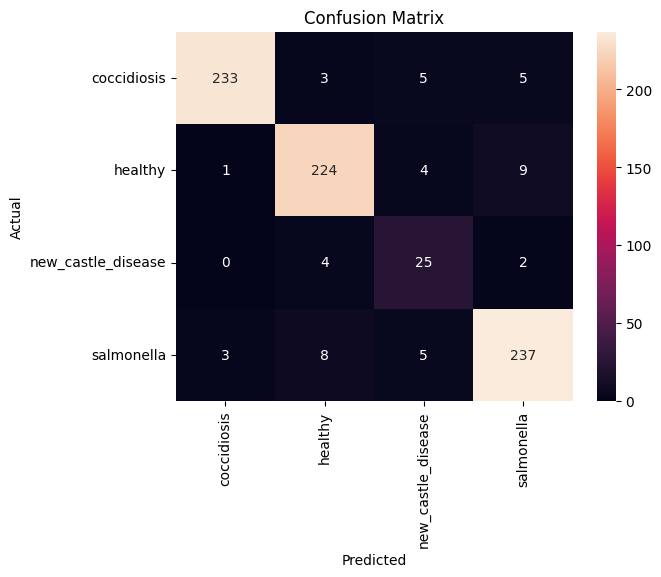

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=le.classes_))

                    precision    recall  f1-score   support

       coccidiosis       0.98      0.95      0.96       246
           healthy       0.94      0.94      0.94       238
new_castle_disease       0.64      0.81      0.71        31
        salmonella       0.94      0.94      0.94       253

          accuracy                           0.94       768
         macro avg       0.87      0.91      0.89       768
      weighted avg       0.94      0.94      0.94       768



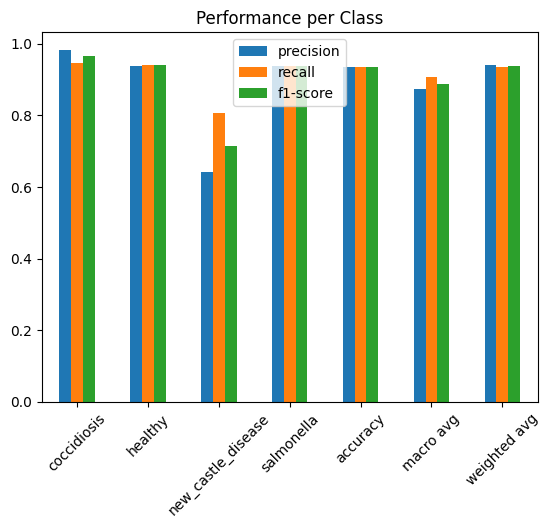

In [26]:
import pandas as pd

report = classification_report(
    y_true, y_pred,
    target_names=le.classes_,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

df_report[['precision','recall','f1-score']].plot(kind='bar')
plt.title("Performance per Class")
plt.xticks(rotation=45)
plt.show()

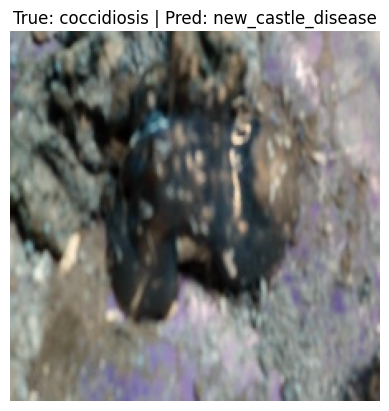

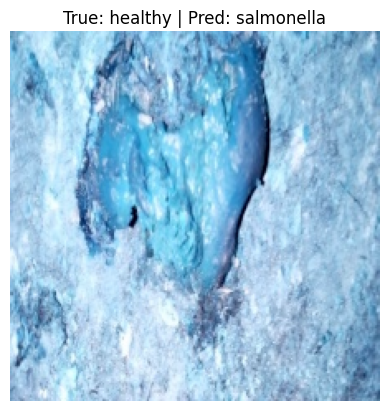

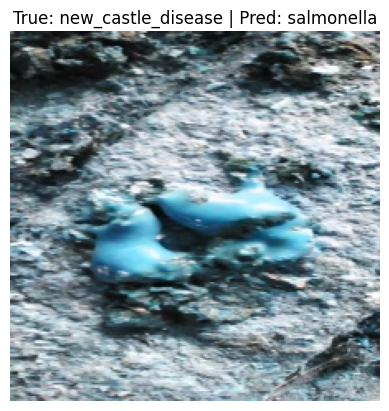

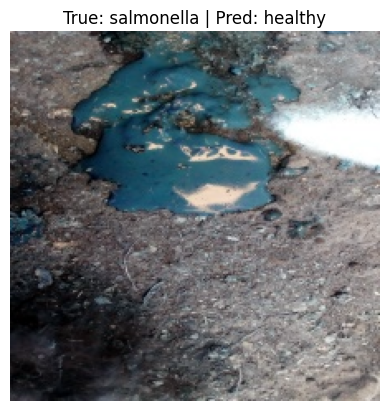

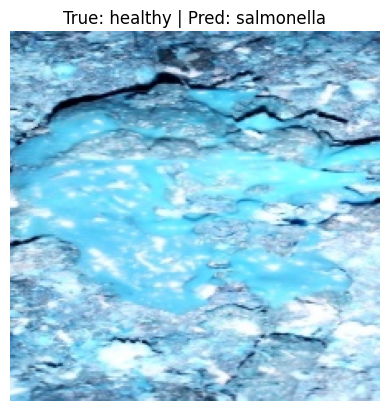

In [27]:
wrong_idx = np.where(y_true != y_pred)[0]

for i in wrong_idx[:5]:
    img = load_image(test_df.iloc[i]['image_path'])
    
    plt.imshow(img)
    plt.title(
        f"True: {le.inverse_transform([y_true[i]])[0]} | "
        f"Pred: {le.inverse_transform([y_pred[i]])[0]}"
    )
    plt.axis('off')
    plt.show()

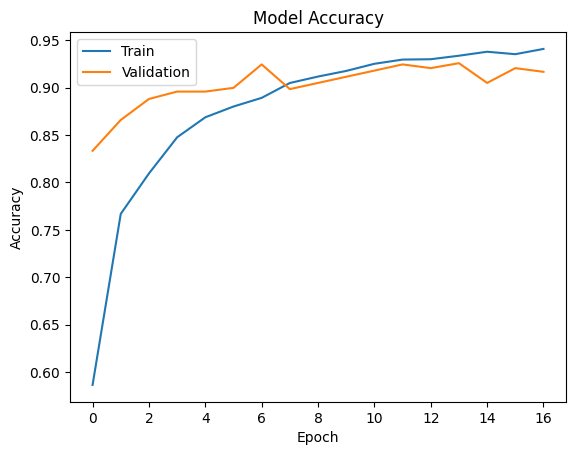

In [28]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

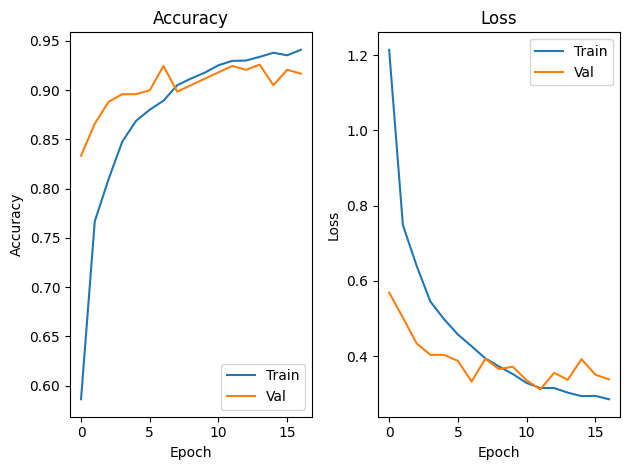

In [29]:
plt.figure()

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Val'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'])

plt.tight_layout()
plt.show()

In [30]:
model.save("multimodal_model.h5")

In [31]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [32]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)